# Imports & Setup

In [85]:
import sys
import os
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

sns.set(style="whitegrid")

BASE_DIR = Path().resolve().parent
sys.path.append(os.path.abspath('scripts'))

from data_cleaning import load_data, clean_data

# Data Loading

In [86]:
path = BASE_DIR / "data/Walmart_Sales.csv"
df = load_data(path)
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Data Cleaning

In [87]:
df = clean_data(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2565 entries, 0 to 6432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         2565 non-null   int64         
 1   Date          2565 non-null   datetime64[ns]
 2   Weekly_Sales  2565 non-null   float64       
 3   Holiday_Flag  2565 non-null   int64         
 4   Temperature   2565 non-null   float64       
 5   Fuel_Price    2565 non-null   float64       
 6   CPI           2565 non-null   float64       
 7   Unemployment  2565 non-null   float64       
 8   Year          2565 non-null   int32         
 9   Month         2565 non-null   int32         
 10  Week          2565 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 212.9 KB


# Exploratory Data Analysis

In [88]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
count,2565.000000,2565,2.565000e+03,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.000000,2565.0
mean,23.000000,2011-05-29 11:47:22.105263104,1.059872e+06,0.105263,59.585864,3.329579,171.386349,8.022267,2010.929825,6.561404,25.157895
min,1.000000,2010-01-10 00:00:00,2.099862e+05,0.000000,-2.060000,2.513000,126.085452,3.879000,2010.000000,1.000000,1.0
25%,12.000000,2010-10-09 00:00:00,5.700695e+05,0.000000,45.260000,2.868000,131.586613,6.908000,2010.000000,4.000000,13.0
50%,23.000000,2011-05-08 00:00:00,9.813452e+05,0.000000,61.100000,3.417000,182.598306,7.907000,2011.000000,6.000000,23.0
75%,34.000000,2012-02-03 00:00:00,1.450733e+06,0.000000,74.570000,3.702000,212.512605,8.622000,2012.000000,10.000000,40.0
max,45.000000,2012-12-10 00:00:00,2.752122e+06,1.000000,100.070000,4.468000,227.169392,14.313000,2012.000000,12.000000,50.0
std,12.989706,NaN,5.573831e+05,0.306952,19.069276,0.461985,39.293112,1.878158,0.791769,3.459797,15.108178


In [126]:
top_ten_weeks = df.sort_values(by="Weekly_Sales", ascending=False).head(10)
top_ten_weeks[['Date', 'Weekly_Sales']]

,Date,Weekly_Sales
2761,2010-10-12,2752122.08
1859,2010-05-02,2623469.95
1903,2010-10-12,2600519.26
2830,2012-06-04,2565259.92
2813,2011-09-12,2546123.78
525,2011-09-12,2508955.24
1867,2010-02-04,2495630.51
1955,2011-09-12,2470581.29
542,2012-06-04,2470206.13
2822,2012-10-02,2462978.28


# Visualization

# Sales Trend Over Time

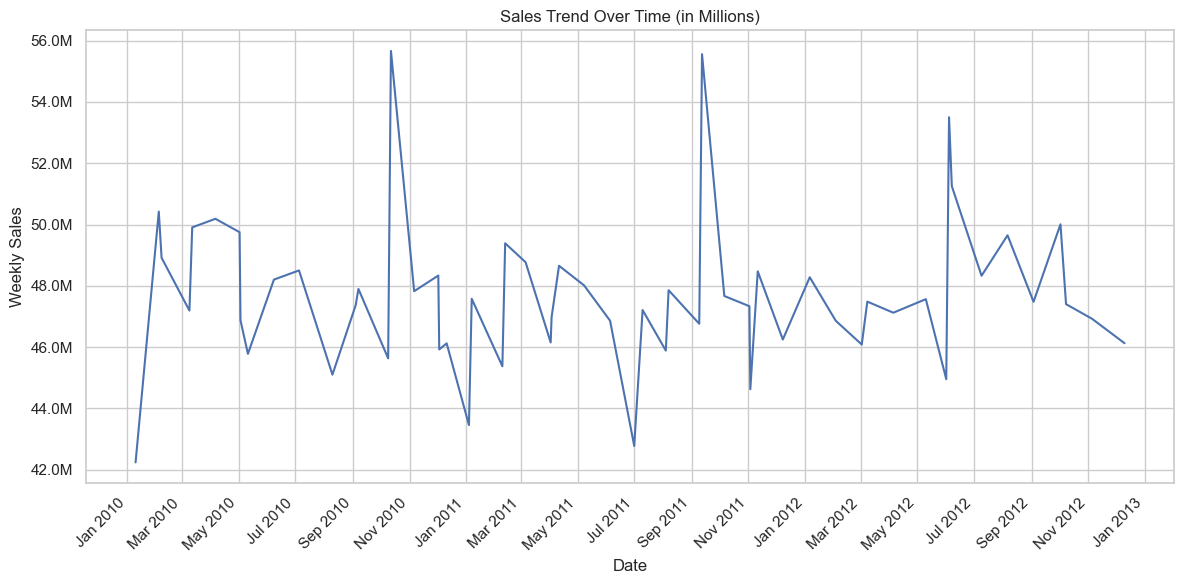

In [92]:
df = df.sort_values('Date')
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()
ax = sales_trend.plot(figsize=(12,6))

# Format Y axis (millions)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

# Format X axis (dates)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.title("Sales Trend Over Time (in Millions)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()

plt.savefig(BASE_DIR / "outputs/plots/sales_trend.png")
plt.show()

# Store-wise Sales

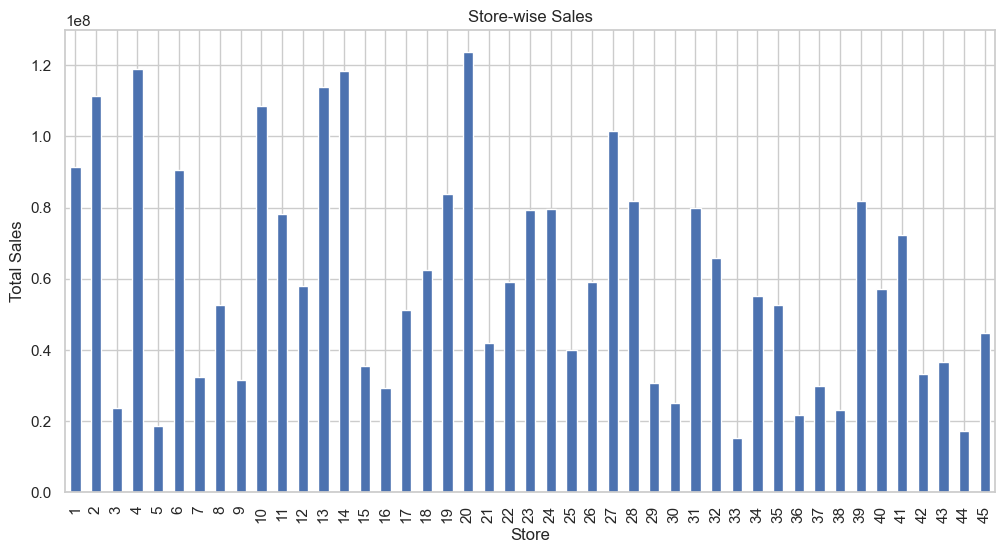

In [96]:
df = df.sort_values('Store')
store_sales = df.groupby('Store')['Weekly_Sales'].sum()
store_sales.plot(figsize=(12, 6), kind="bar")

plt.title("Store-wise Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.savefig(BASE_DIR / "outputs/plots/store_sales.png")
plt.show()

# Holiday vs Non-Holiday

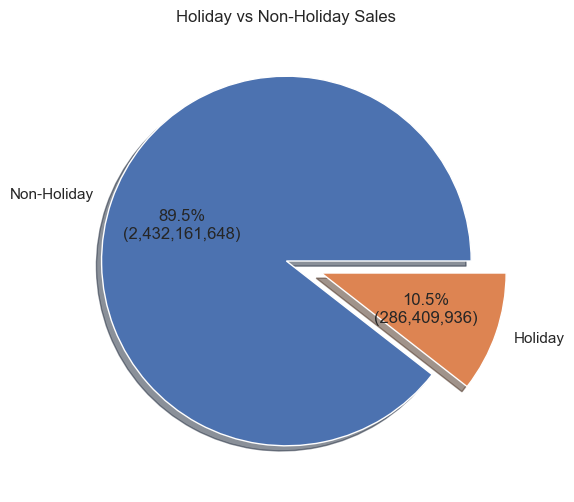

In [112]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].sum()

y = holiday_sales.values
labels = ['Non-Holiday', 'Holiday']

plt.figure(figsize=(6,6))

plt.pie(
    y,
    labels=labels,
    explode=[0, 0.2],
    shadow=True,
    autopct=lambda p: f'{p:.1f}%\n({p * sum(y) / 100:,.0f})'
)

plt.title("Holiday vs Non-Holiday Sales")

plt.savefig(BASE_DIR / "outputs/plots/holiday_sales.png")
plt.show()

# Correlation Heatmap

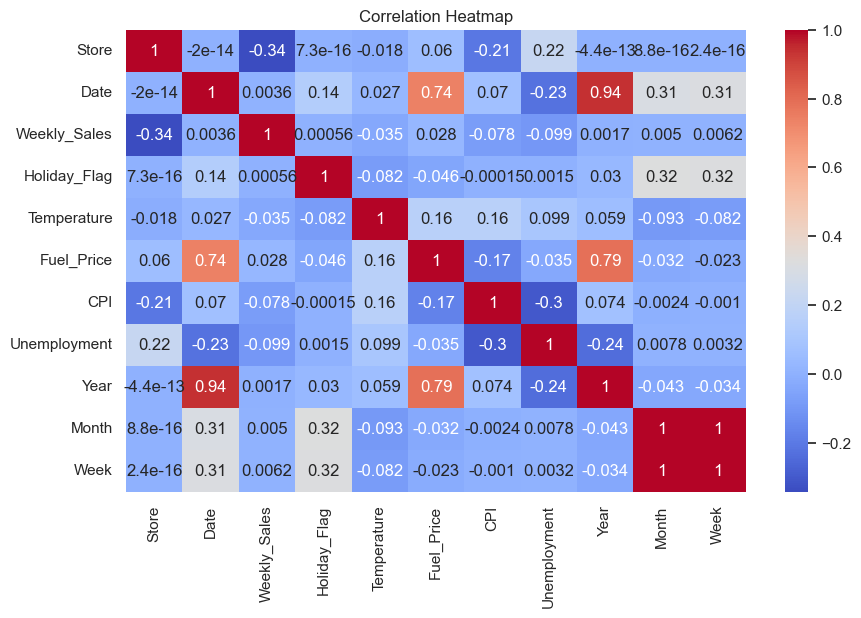

In [115]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig(BASE_DIR / "outputs/plots/correlation_heatmap.png")
plt.show()

# Monthly Sales

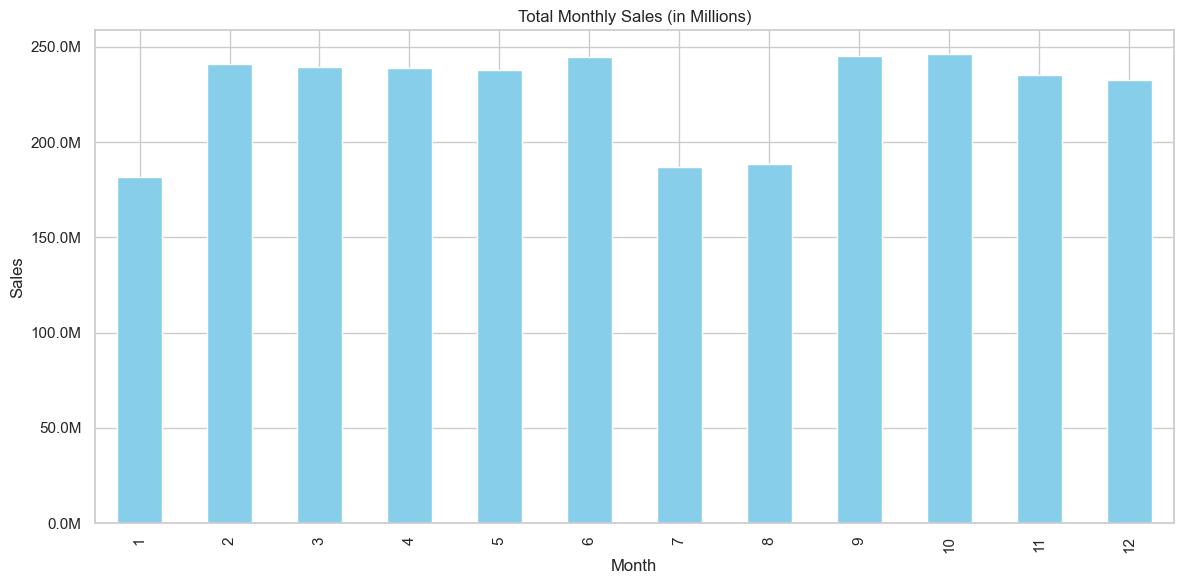

In [118]:
ax = monthly_sales.plot(kind='bar', figsize=(12,6), color='skyblue')

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.title("Total Monthly Sales (in Millions)")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs/plots/monthly_sales.png")
plt.show()

# Temperature vs Sales

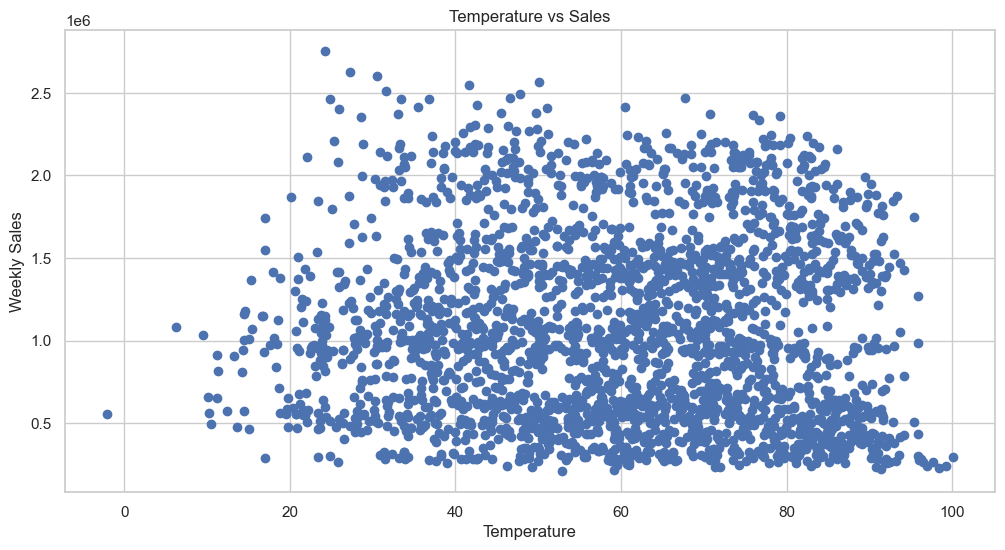

In [124]:
plt.figure(figsize=(12, 6))
plt.scatter(df['Temperature'], df['Weekly_Sales'])

plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.title("Temperature vs Sales")

plt.savefig(BASE_DIR / 'outputs/plots/temperature_vs_sales.png')
plt.show()